# Methodology: Smart Glasses Simulation Using CNNs

## 1. Dataset Overview
- Using COCO 2017 dataset: 80 object classes, real-world images, annotations.
- Only using subset from `train2017` for simplicity.

## 2. Loading and Visualizing Data
- Load annotations from JSON.
- Visualize sample image with bounding boxes and class labels.

## 3. CNN Model Selection
- We will use a pre-trained YOLOv5 (lightweight version).
- Detect objects and simulate "feedback" by printing out object names.


In [1]:
import os
import json
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from pycocotools.coco import COCO

# Path setup
data_dir = '/kaggle/input/coco-2017-dataset/coco2017'
train_images = os.path.join(data_dir, 'train2017')
ann_file = os.path.join(data_dir, 'annotations/instances_train2017.json')

# Load COCO annotations
coco = COCO(ann_file)

# Get category names
cats = coco.loadCats(coco.getCatIds())
cat_names = [cat['name'] for cat in cats]
print(f"COCO Categories ({len(cat_names)}):")
print(cat_names)


loading annotations into memory...
Done (t=26.76s)
creating index...
index created!
COCO Categories (80):
['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


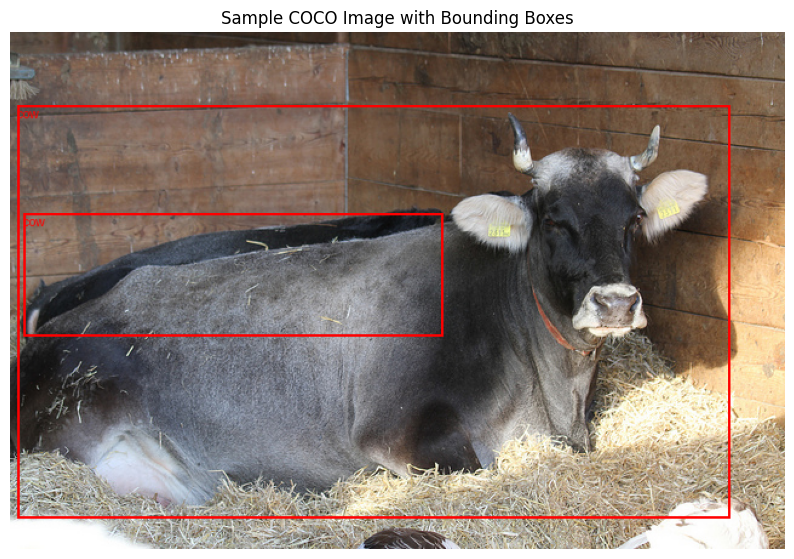

In [2]:
import random
from matplotlib.patches import Rectangle

# Get all image IDs
image_ids = coco.getImgIds()

# Pick a random image ID
img_id = random.choice(image_ids)
img_info = coco.loadImgs(img_id)[0]

# Load the image
img_path = os.path.join(train_images, img_info['file_name'])
image = Image.open(img_path)

# Load annotations
ann_ids = coco.getAnnIds(imgIds=img_info['id'])
anns = coco.loadAnns(ann_ids)

# Draw bounding boxes
draw = ImageDraw.Draw(image)
for ann in anns:
    bbox = ann['bbox']
    category_id = ann['category_id']
    label = coco.loadCats(category_id)[0]['name']
    draw.rectangle(
        [bbox[0], bbox[1], bbox[0]+bbox[2], bbox[1]+bbox[3]],
        outline='red',
        width=2
    )
    draw.text((bbox[0], bbox[1]), label, fill='red')

# Show the image
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off')
plt.title("Sample COCO Image with Bounding Boxes")
plt.show()


In [3]:
# Clone YOLOv5 repo
!git clone https://github.com/ultralytics/yolov5.git
%cd yolov5
!pip install -r requirements.txt


Cloning into 'yolov5'...
remote: Enumerating objects: 17777, done.
remote: Counting objects: 100% (161/161), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 17777 (delta 98), reused 55 (delta 54), pack-reused 17616 (from 2)
Receiving objects: 100% (17777/17777), 17.14 MiB | 26.47 MiB/s, done.
Resolving deltas: 100% (12076/12076), done.
/kaggle/working/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB

/usr/local/lib/python3.11/dist-packages/torch/hub.py:330: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


YOLOv5 🚀 2025-12-28 Python-3.11.13 torch-2.6.0+cu124 CPU

100%|██████████| 14.1M/14.1M [00:00<00:00, 180MB/s]

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 427x640 1 cow
Speed: 25.5ms pre-process, 209.7ms inference, 20.6ms NMS per image at shape (1, 3, 448, 640)


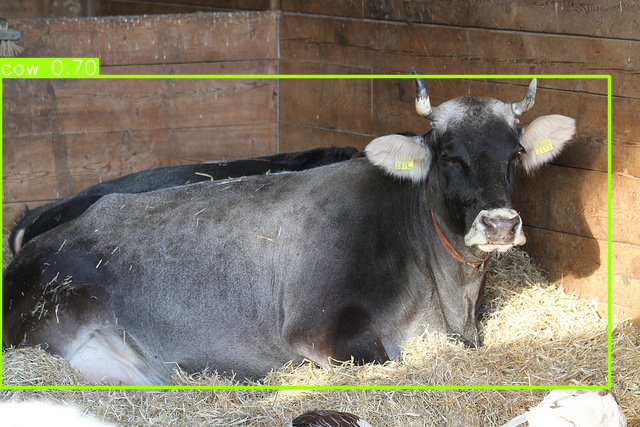

In [4]:
import torch
from IPython.display import Image as IPImage

# Load pretrained YOLOv5 model (YOLOv5s = small, fast, accurate enough)
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

# Use the same image you loaded before
results = model(img_path)

# Show predictions
results.print()  # class labels and confidence scores
results.show()   # visual output (bounding boxes on image)


In [5]:
!pip install pyttsx3
!apt-get install -y espeak ffmpeg libespeak1





ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
The following additional packages will be installed:
  espeak-data libportaudio2 libsonic0
The following NEW packages will be installed:
  espeak espeak-data libespeak1 libportaudio2 libsonic0
0 upgraded, 5 newly installed, 0 to remove and 38 not upgraded.
Need to get 1,382 kB of archives.
After this operation, 3,178 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libportaudio2 amd64 19.6.0-1.1 [65.3 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libsonic0 amd64 0.2.0-11build1 [10.3 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 espeak-data amd64 1.48.15+dfsg-3 [1,085 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libespeak1 amd64 1.48.15+dfsg-3 [156 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy/universe amd64 espeak amd64 1.48.15+dfsg-3 [64.2 kB]
Fetched 1,382 kB in 1s (1,969 kB/s)
Selecting previously unselected pa

In [6]:
!pip install gTTS


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 3.3 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.2.1
    Uninstalling click-8.2.1:
      Successfully uninstalled click-8.2.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
preprocessing 0.1.13 requires nltk==3.2.4, but you have nltk 3.9.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
bigframes 2.8.0 requires google-cloud-bigquery[bqstorage,pandas]>=3.31.0, but you have google-cloud-bigquery 3.25.0 which is incompatible.
bigframes 2.8.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.


In [7]:
from gtts import gTTS
from IPython.display import Audio

# Extract detected class names
detected_names = results.names
detected_classes = results.pred[0][:, -1].tolist()
labels = [detected_names[int(cls)] for cls in detected_classes]

# Unique object labels
spoken_output = "I see: " + ", ".join(sorted(set(labels)))
print(spoken_output)

# Convert text to speech
tts = gTTS(text=spoken_output, lang='en')
tts.save("detected_objects.mp3")

# Play the audio
Audio("detected_objects.mp3")


I see: cow
